# TorchVision for Pre-Processing

Welcome to the first lab of this module! Before a deep learning model can learn to "see", the visual data you feed it must be carefully prepared. Raw images come in various sizes and formats, but neural networks require a standardized input, specifically, a **tensor**.

This is where **TorchVision** comes in. As PyTorch’s standard toolkit for computer vision, it provides powerful and efficient tools designed to handle the common, often tedious, components of a vision workload. Instead of reinventing the wheel, you can use TorchVision’s battle tested data pipelines and functions to focus on building innovative models.

In this lab, you will:

* Practice converting images between the common **Pillow (PIL)** image format and **PyTorch Tensors**.
* Explore handy **TorchVision utilities** like `make_grid` and `save_image` to simplify debugging and visualize batches of images.
* Apply individual transformations to resize, crop, and augment images, and see their effects.
* Define and implement a **custom transformation** from scratch to add a unique effect on the dataset.
* Chain transforms together using `transforms.Compose` to build powerful and reusable **preprocessing and data augmentation pipelines**.

By the end of this lab, you'll have a solid understanding of how to build a complete image preparation workflow from the ground up.

In [1]:
import os

from IPython.display import Image as DisplayImage
import numpy as np
from PIL import Image
import torch
import torch.utils.data as data
from torchvision import datasets
from torchvision.io import decode_image
import torchvision.transforms as transforms
import torchvision.utils as vutils
from tqdm.auto import tqdm

import preprocessing_helper

In [2]:
#Check if data folder exists
ox3_pet_data_apth = "./oxford3pet_data"
if os.path.exists(ox3_pet_data_apth) and os.path.isdir(ox3_pet_data_apth):
    ox3_pet_download = False
else:
    ox3_pet_download = True

## Image Conversion (PIL and Tensor)

Your first practical step in any computer vision workflow is to bridge the gap between how humans see images and how machines process them. An image file is a grid of pixels, often handled by a library like Pillow (PIL). A neural network, however, requires a numerical format it can perform calculations on: a **Tensor**.

Gaining fluency in converting between these two formats is a foundational skill. It's the mechanism that lets you load, process, and inspect your data at every stage of a project.

To begin, you will perform a "roundtrip" conversion. By taking a PIL image, changing it to a PyTorch Tensor, and then converting it back, you'll confirm that this core operation is seamless and preserves your data perfectly. This is a vital sanity check before building more complex pipelines.

* Load an image with Pillow from a file using the Pillow (PIL) library.
    * Note that Pillow reports dimensions in `(Width, Height)` format.

In [3]:
#Load an image
image = Image.open('./images/mangoes.jpg')

#Dimensions of the original PIL image
print("Original PIL image dimensions:", image.size)
print(f"The maximum pixel value is: {image.getextrema()[0][1]}, and the minimum is: {image.getextrema()[0][0]}")

Original PIL image dimensions: (2048, 2048)
The maximum pixel value is: 255, and the minimum is: 0


<br>

* `transforms.ToTensor()`: Converts a PIL image object into a PyTorch Tensor.
    * **Dimension Change**: This transform rearranges the image data from Pillow's `(Width, Height)` format to PyTorch's `(Channels, Height, Width)` format.  It also scales the image's pixel values from the `[0, 255]` range to a floating point `[0.0, 1.0]` range.

In [4]:
#Convert the PIL image to a PyTorch Tensor
img_tensor = transforms.ToTensor()(image)

#Dimensions (shape) of the tensor
#[C, H, W] format
print(f"Dimension after converting to a tensor: {img_tensor.shape}")
print(f"The maximum pixel valueis: {img_tensor.max()}, and the minimum is: {img_tensor.min()}")

Dimension after converting to a tensor: torch.Size([3, 2048, 2048])
The maximum pixel valueis: 1.0, and the minimum is: 0.0


<br>

* `transforms.ToPILImage()`: Converts a PyTorch Tensor back into a PIL image object.
    * **Dimension Change**: It performs the reverse, converting a `(Channels, Height, Width)` tensor back into a PIL image that reports its size as `(Width, Height)`.

In [5]:
#Convert the tensor back to a PILimage
img_pil = transforms.ToPILImage()(img_tensor)

#Dimension of the convered back PIL image
print("Dimensions after converting back to PIL:", img_pil.size)

Dimensions after converting back to PIL: (2048, 2048)


<br>

* Display the original and the converted images side-by-side to visually confirm that the "roundtrip" process preserved the image content perfectly.

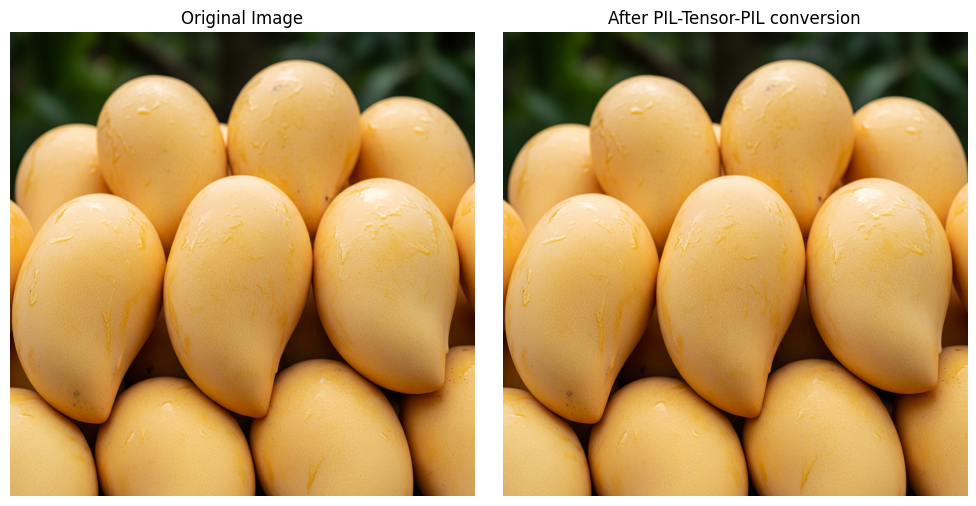

In [6]:
#Visualize the original and convered iamges 
preprocessing_helper.show_images([image,img_pil], titles=("Original Image", "After PIL-Tensor-PIL conversion"))

## TorchVision Utilities for Image Handling

TorchVision equips you with a powerful toolkit for the practical logistics of a computer vision project. These utilities are designed to manage the entire lifecycle of your image data, from initial loading to final output. Mastering them allows you to efficiently load data, debug your pipeline by visualizing what your model is seeing, and save your results professionally.

You will now explore three indispensable functions that address these core needs:

* `decode_image`: Instantly converts compressed image files like JPEGs or PNGs directly into tensors.

* `make_grid`: Arranges a batch of images into a clean, single grid, which is perfect for at-a-glance inspection and analysis.

* `save_image`: Saves your tensor-based images back to a standard file format, making it easy to share results for reports or presentations.

### Decoding Images into Tensors with `decode_image`

The `decode_image` function is designed for one primary purpose: to efficiently convert an image file directly into a **numerical PyTorch tensor** for computation. It reads an image and immediately returns a tensor in the `[Channels, Height, Width]` format, ready for subsequent processing. Unlike `Image.open`, which returns a visual PIL object for immediate display or editing, the tensor from `decode_image` is a purely numerical object. This makes it the ideal choice when your workflow begins with computation, not visualization.

* <code>[decode_image()](https://docs.pytorch.org/vision/stable/generated/torchvision.io.decode_image.html)</code>: Loads an image (e.g., JPEG, PNG) and converts it into a `torch.uint8` PyTorch Tensor.
    * **Dimension Ordering**: The output tensor follows the standard PyTorch **channel-first convention** (`[C, H, W]`), which important for model compatibility. 'C' is the number of channels (e.g., 3 for an RGB image), 'H' is height, and 'W' is width.

In [8]:
image_path = './images/apples.jpg'

#Load the image 
image = decode_image(image_path)

print(f"Image tensor dimensions: {image.shape}")
print(f"Image tensor dtype: {image.dtype}")
print(f"The maximum pixel value is {image.max()}, and the minimum is: {image.min()}")

Image tensor dimensions: torch.Size([3, 2048, 2048])
Image tensor dtype: torch.uint8
The maximum pixel value is 255, and the minimum is: 0


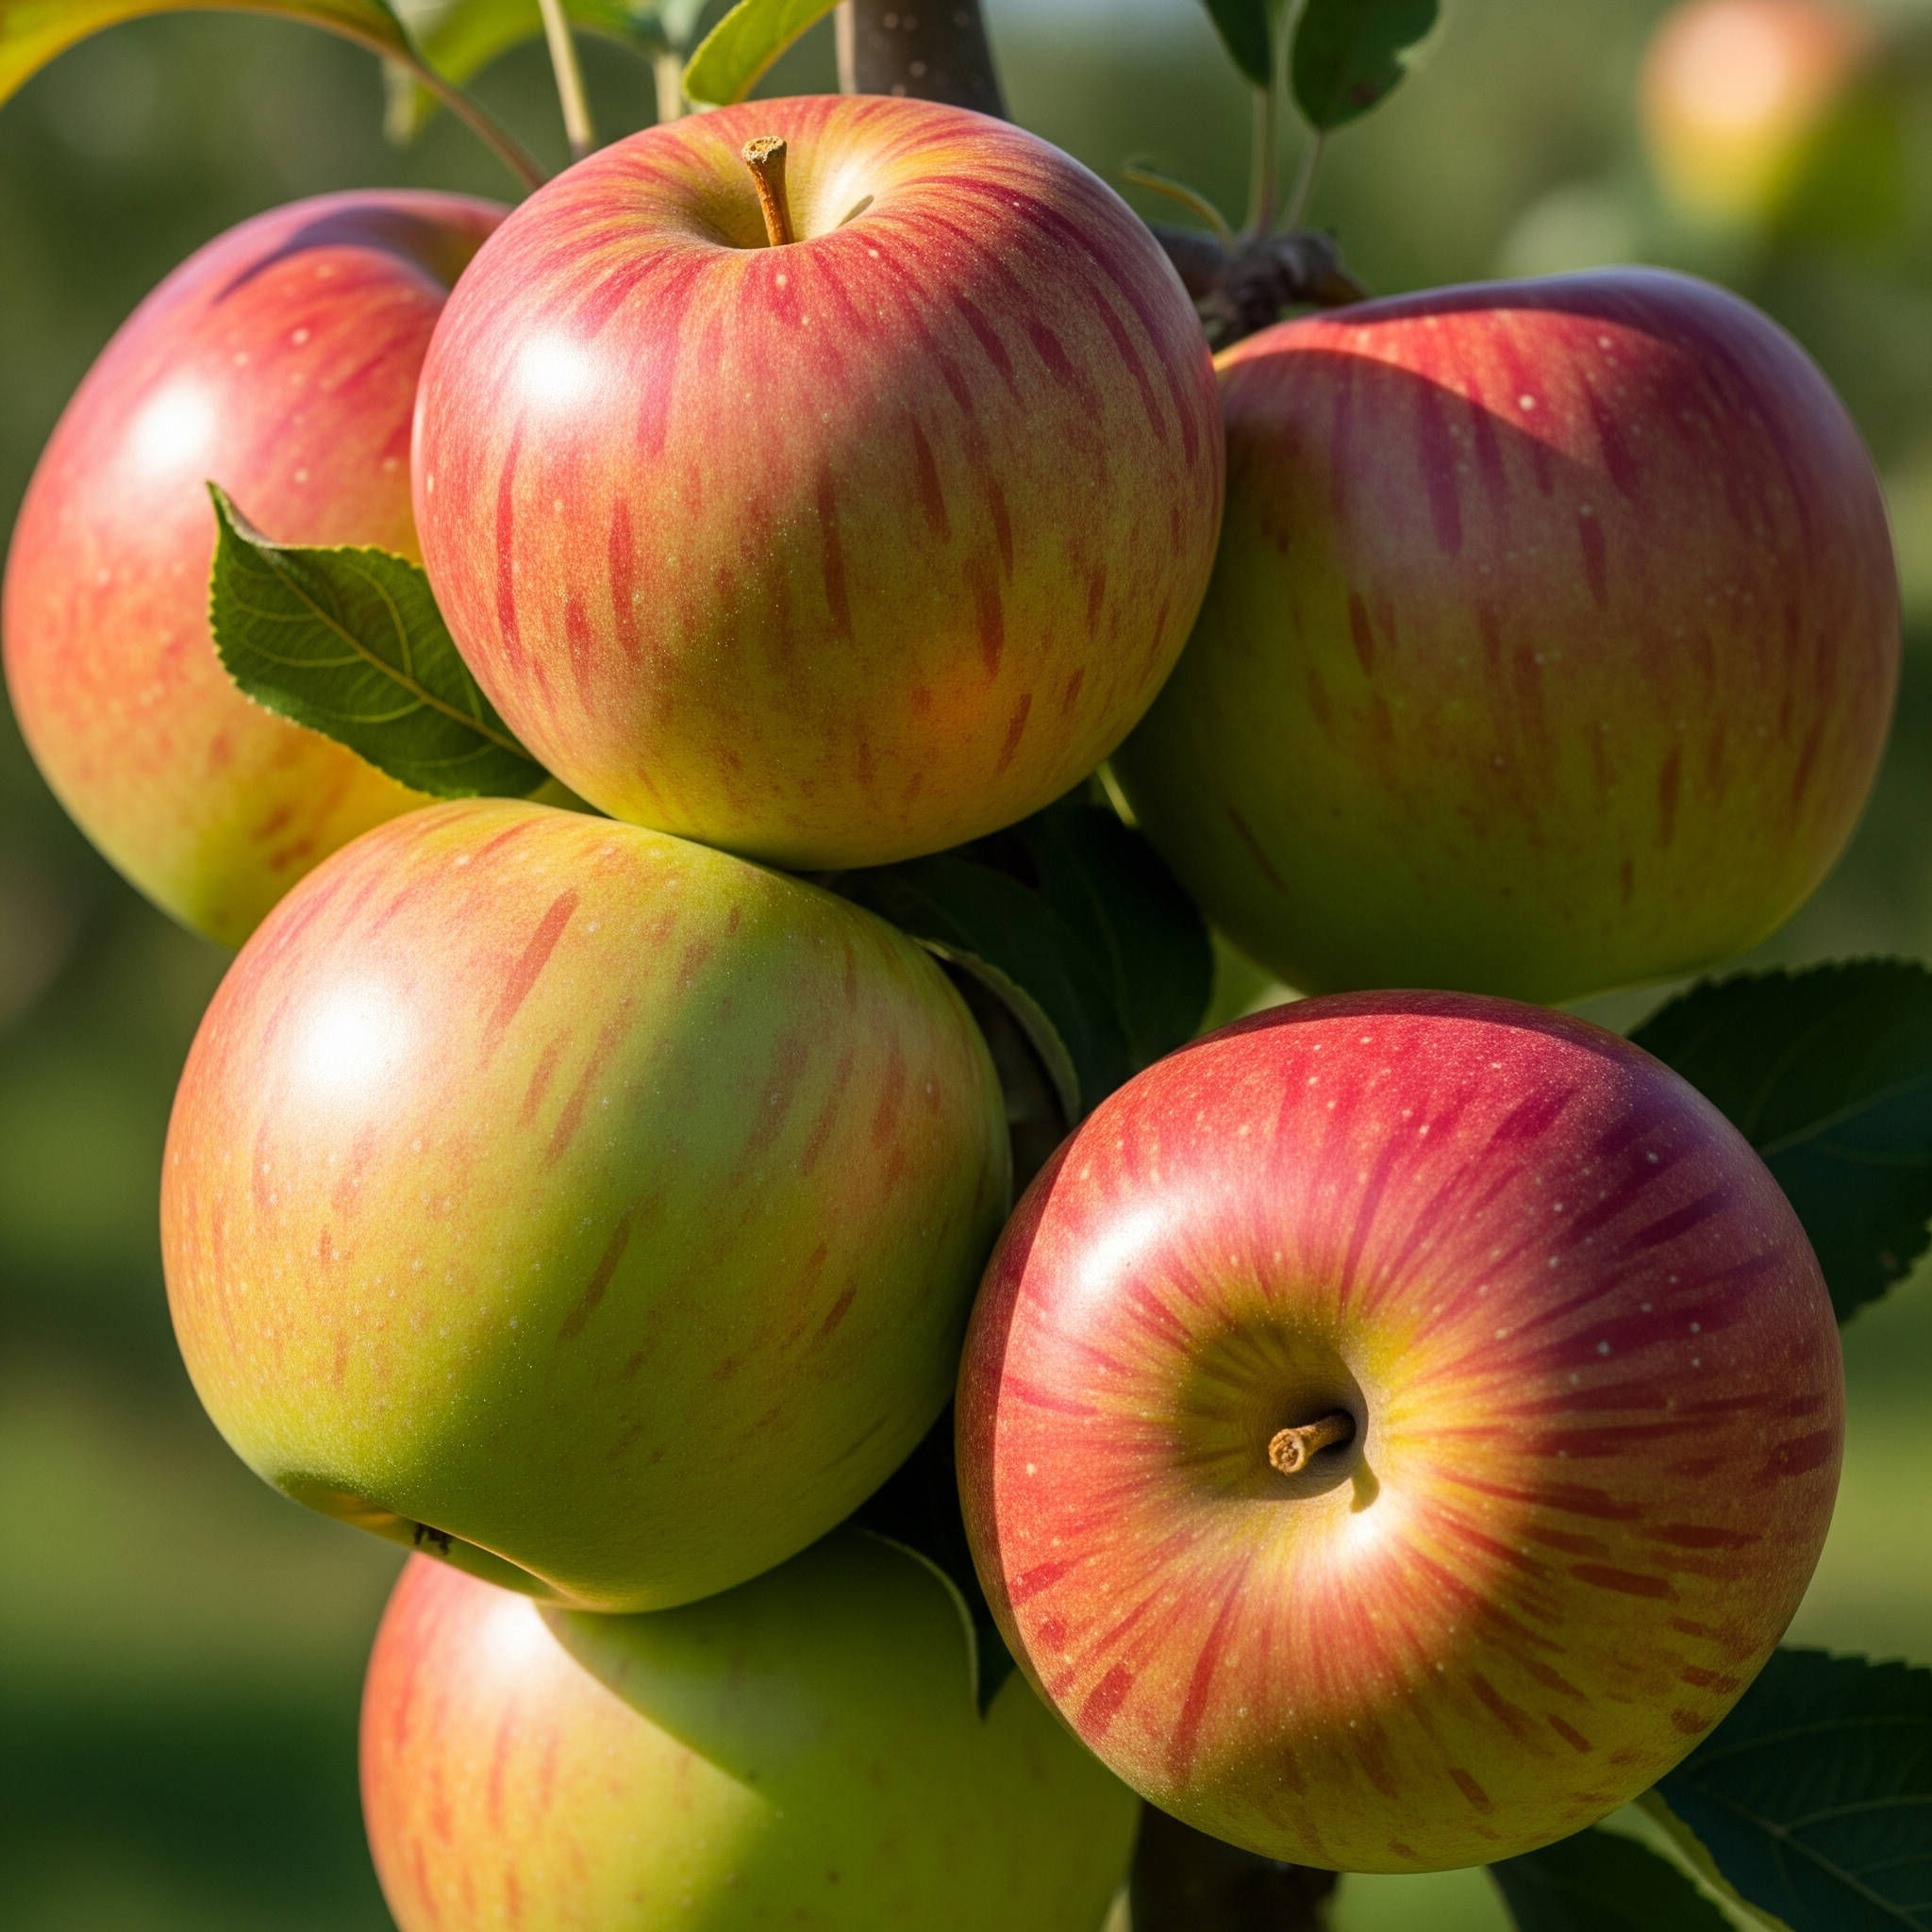

In [9]:
#Use the DisplayImage to render the image
DisplayImage(image_path, width=500, height=500)

### Creating Image Grids with `make_grid`

In deep learning, you almost always process data in **batches**, not single images. But how do you get a quick, holistic view of an entire batch at once? Displaying them individually is inefficient.

The `make_grid` function is the professional solution to this common challenge. It’s an essential utility that takes a batch of image tensors and arranges them into a single, clean grid for easy inspection. This is a vital step for visual debugging, allowing you to instantly check the results of your data augmentation or see exactly what a `DataLoader` is feeding to your model.

* Load a batch of images from a local folder (`"./images/"`).
    * The images are loaded as a single tensor containing all the image data, which is what the `make_grid` function expects.

In [10]:
#Create a batch of images.
images_tensor = preprocessing_helper.load_images("./images/")

#The size is 6 images X 3 color channels X 300 pixel height and width
print(f"Image tensor dimensions: {images_tensor.shape}")

Image tensor dimensions: torch.Size([6, 3, 300, 300])


* Arrange the loaded images into a grid using the <code>[make_grid()](https://docs.pytorch.org/vision/main/generated/torchvision.utils.make_grid.html)</code> function.
    * `tensor:` This needs to be a batch of images, as a **4D tensor** (`(B x C x H x W)`), to be placed into the grid.
    * `nrow=3`: Arranges the images with **3 images in each row**.
    * `padding=5`: Adds **5 pixels** of space between the images.
    * `normalize=True`: Shifts the image pixel values to a standard range (0 to 1) for consistent display.

Feel free to modify the parameters, and observe how it affects the image.

In [ ]:
#make a grid from the loaded iamges (2 rows of 3 for 6 images)
grid =vutils.make_grid(tensor=images_tensor, nrow=3, padding=5, normalize=True)

# the shape comes from 
# num_images/nrow*pixel_height+(num_images/nrow+1)*padding = 2*300+3*5 = 615
# nrow*pixel_width+(nrow+1)*padding = 3*300+4*5 = 920
print(f"Image tensor dimension: {grid.shape}")
print(f"The maximun pixel value is {grid.max()}, and the minimum is: {grid.min()}")

preprocessing_helper.display_grid(grid)